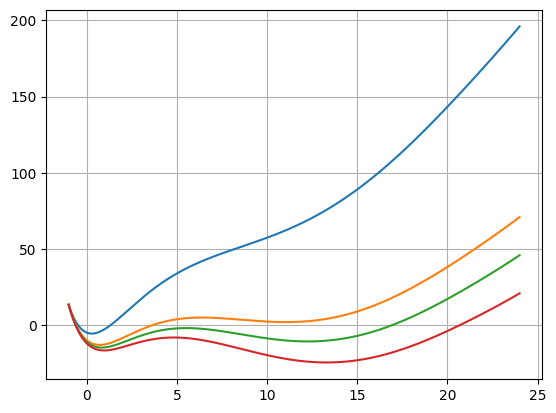

In [187]:
# th simulation

## fitting on smooth - xdag

# FITTING
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from cycler import cycler
plt.rcParams.update({"axes.prop_cycle": cycler(color=["#000000","#E69F00","#56B4E9","#009E73","#F0E442","#0072B2","#D55E00","#CC79A7"]), "image.cmap":"viridis"})
plt.style.use('default')

kT = 4.11 #pN 
z = np.linspace(-4, 39, 350) 
lc, lp = 40, 0.45
k = 0.7 #3*kT/ (0.45* 70)
a, G0, U0, s, x_dag, lc, lp = 0.33, 87, 87, 118, 25, 40, 0.45 

for F in (5, 10, 11, 12):

# Talin 
    def F_wlc(dz, lc= 40, lp= 0.5):
        Fwlc = (kT / lp) * (1 / 4 * (1 - dz / lc)**(-2) + dz / lc - 1/4)
        return Fwlc
    
    def U_wlc(z, F, lc, lp):
        U = (kT / lp) * (-0.25 * (lc**2) / (z - lc) + z**2 / (2 * lc) - 0.25 * z) - F * z
        return U
    def U_fold_fit(z, a, G0, U0, s, x_dag):
        return U0 * (1 - np.exp(-a * z))**2 + G0 * np.exp(-((z - x_dag)**2) / s)
    def U_total_fit(z, a, G0, U0, s, x_dag, lc, lp):
        offset = U_wlc(z, F, lc, lp)[0]  # F deve essere definito globalmente o passato
        return U_wlc(z, F, lc, lp) - offset + U_fold_fit(z, a, G0, U0, s, x_dag)

    popt= 0.33, 87, 87, 118, 25, 40, 0.45  # = a, G0, U0, s, x_dag, lc, lp

    x_fit = np.linspace(-1, 24, 300)
    y_finalfit = U_total_fit(x_fit, *popt)
    plt.plot(x_fit, y_finalfit); plt.grid(True)


C:\Users\bulga\AppData\Local\Temp\ipykernel_15024\780196977.py:20: RuntimeWarning: overflow encountered in sinh
  return kT * N * ( x*y + np.log( np.where(np.abs(y) < 1e-12, 1.0, y/np.sinh(y)) ) )
C:\Users\bulga\AppData\Local\Temp\ipykernel_15024\780196977.py:20: RuntimeWarning: divide by zero encountered in log
  return kT * N * ( x*y + np.log( np.where(np.abs(y) < 1e-12, 1.0, y/np.sinh(y)) ) )


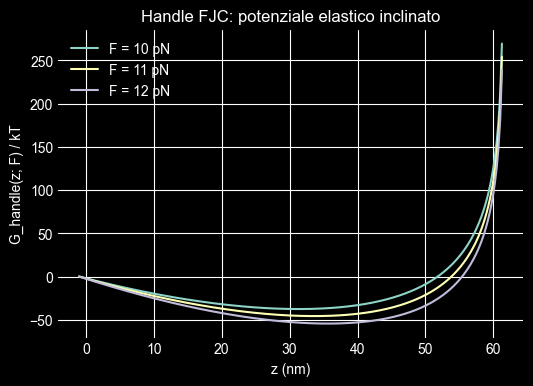

In [157]:
# Re-run (kernel was reset)
import numpy as np
import matplotlib.pyplot as plt

kT = 4.11 
Lc = 70.0 
Lp = 0.45 
L0 = -8.5

def inv_langevin(x):
    x = np.clip(x, -0.999999, 0.999999)
    return x * (3 - x**2) / (1 - x**2)

def U_fjc_mech(z, Lc=70.0, Lp=0.45, L0=L0, kT=kT):
    lk  = 2.0 * Lp
    N  = Lc / lk
    xi = np.asarray(z, float) - L0
    x  = np.clip(xi / Lc, -0.999999, 0.999999)
    y  = inv_langevin(x)
    return kT * N * ( x*y + np.log( np.where(np.abs(y) < 1e-12, 1.0, y/np.sinh(y)) ) )

z= np.linspace(-1, Lc +5, 300)
Fs = [10, 11.0, 12.0]             # pN

plt.figure(figsize=(6,4))
Uh = U_fjc_mech(z, Lc, Lp, L0, kT)

for F in Fs:
    G = Uh - F * z
    G = G - G[0]
    plt.plot(z, G/kT, label=f"F = {F:.0f} pN")

plt.xlabel("z (nm)")
plt.ylabel("G_handle(z; F) / kT")
plt.title("Handle FJC: potenziale elastico inclinato")
plt.legend()
plt.grid(True)
plt.show()


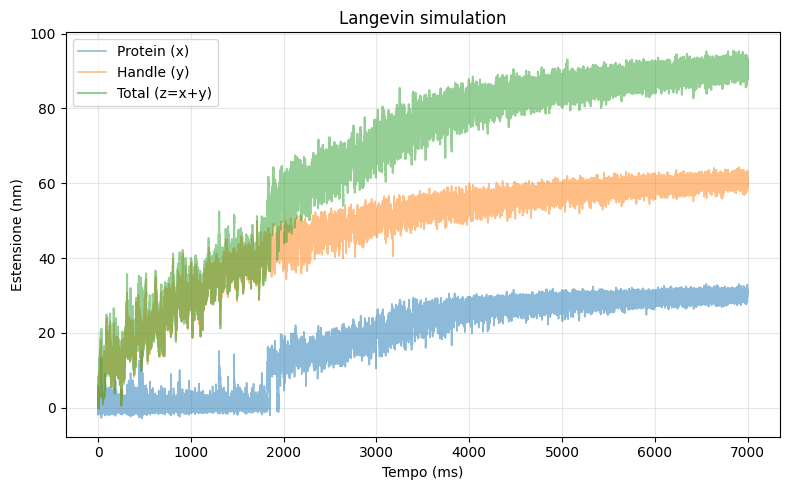

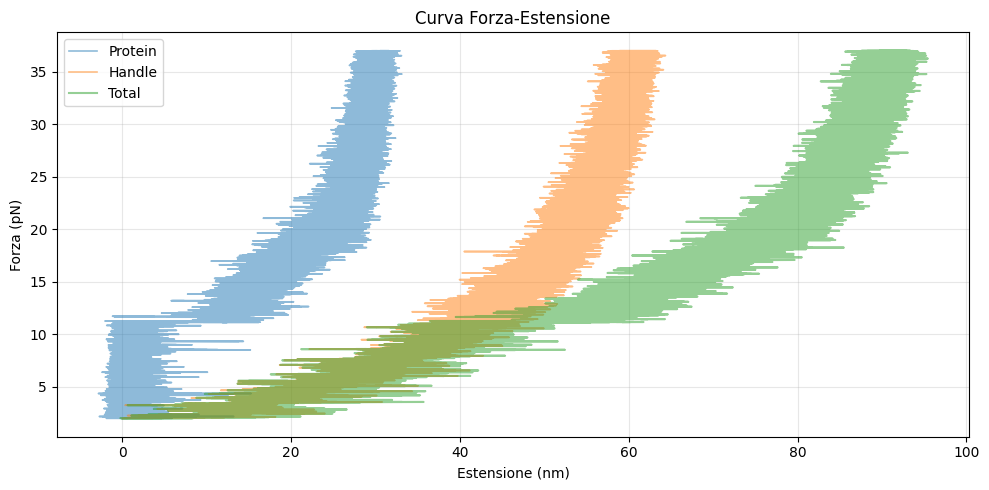

Fext finale = 37.0 pN
<x>, <y>, <z>  = 18.48, 47.38, 65.86 nm


In [ ]:
import numpy as np

kT = 4.11
Lc_p, Lp_p, L0_p = 40.0, 0.45, 0.0 # nm
Lc_h, Lp_h, L0_h = 70.0, 0.45, 0.0  # nm
D= 3200 #nm2/s

# rampa di forza F(t) = F0 + r*t
F0, r = 2.0, 5.0   # pN, pN/s

dt, T = 1e-4, 7
N = int(T/dt)
rng = np.random.default_rng(1)

# fjc
def inv_langevin(x):
    x = np.clip(x, -0.999999, 0.999999)
    return x*(3 - x**2)/(1 - x**2)

# WLC
def F_wlc(x, Lc=Lc_p, Lp=Lp_p, L0=L0_p, kT=kT):
    xi = np.asarray(x) - L0
    xi = np.clip(xi, -0.25*Lc, Lc - 1e-6)
    return (kT/Lp)*(0.25*(1 - xi/Lc)**(-2) + xi/Lc - 0.25)  + 2*a*U0*(1- np.exp(-a*x)) * np.exp(-a*x) - 2*G0*(x - x_dag)/s * np.exp(-(x-x_dag)**2/s)

# FJC per HANDLE
def F_fjc(y, Lc=Lc_h, Lp=Lp_h, L0=L0_h, kT=kT):
    lk = 2.0*Lp
    xi = np.asarray(y) - L0
    x  = np.clip(xi/Lc, -0.999999, 0.999999)
    return (kT/lk)*inv_langevin(x)

# --------- simulazione (force clamp ramp) ---------
t = np.arange(N)*dt
x = np.zeros(N)  # estensione proteina
y = np.zeros(N)  # estensione handle
z = np.zeros(N)

nx = np.sqrt(2*D*dt)
ny = np.sqrt(2*D*dt)

for i in range(N-1):
    Fext = F0 + r*t[i]
    Fx = Fext - F_wlc(x[i], Lc_p, Lp_p, L0_p, kT)   # γx xdot = Fext - Fint_p + noise
    Fy = Fext - F_fjc(y[i], Lc_h, Lp_h, L0_h, kT)  # γy ydot = Fext - Fint_h + noise

    x[i+1] = x[i] + (Fx*D/kT)*dt + nx*rng.normal()
    y[i+1] = y[i] + (Fy*D/kT )*dt + ny*rng.normal()

    # vincoli fisici
    x[i+1] = np.clip(x[i+1], -np.inf, Lc_p - 1e-3)
    y[i+1] = np.clip(y[i+1], 0.0, Lc_h - 1e-3)

    z[i+1] = x[i+1] + y[i+1]

Fext_array = F0 + r * t
plt.figure(figsize=(8, 5))
plt.plot(t * 1e3, x, label="Protein (x)", lw=1.2,  alpha=0.5)
plt.plot(t * 1e3, y, label="Handle (y)", lw=1.2, alpha =0.5 )
plt.plot(t * 1e3, z, label="Total (z=x+y)", lw=1.5,  alpha=0.5)
plt.xlabel("Tempo (ms)")
plt.ylabel("Estensione (nm)")
plt.title("Langevin simulation")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(x, Fext_array, label="Protein", lw=1.2, alpha=0.5)
plt.plot(y, Fext_array, label="Handle", lw=1.2, alpha=0.5)
plt.plot(z, Fext_array, label="Total", lw=1.5,  alpha=0.5)
plt.xlabel("Estensione (nm)")
plt.ylabel("Forza (pN)")
plt.title("Curva Forza-Estensione")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Fext finale = {F0 + r*T:.1f} pN")
print(f"<x>, <y>, <z>  = {x.mean():.2f}, {y.mean():.2f}, {z.mean():.2f} nm")

#il rumore si assottiglia alla fine della traiettoria blu_ vuol dire che sto riducendo errore 
